shape = (506, 900) dtype = uint8
min = 0 max = 255
mean = 83.55 std = 49.05


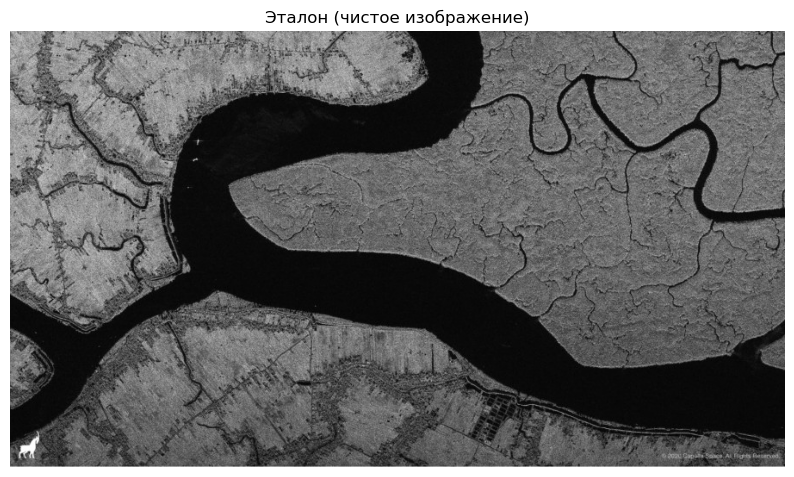

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse_func
import pandas as pd

# Загрузка эталона
img_clean = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
assert img_clean is not None, "Файл sar_1_gray.jpg не найден!"

print("shape =", img_clean.shape, "dtype =", img_clean.dtype)
print("min =", img_clean.min(), "max =", img_clean.max())
print("mean =", round(float(img_clean.mean()), 2),
      "std =", round(float(img_clean.std()), 2))

plt.figure(figsize=(10, 6))
plt.imshow(img_clean, cmap='gray')
plt.title('Эталон (чистое изображение)')
plt.axis('off')
plt.show()

In [2]:
def quality(clean, processed):
    """Возвращает (MSE, SSIM) между эталоном и обработанным."""
    mse_val  = mse_func(clean, processed)
    ssim_val = ssim(clean, processed, data_range=255)
    return mse_val, ssim_val

=== Гауссов шум ===
  σ=15 | MSE =   205.28 | SSIM = 0.6692
  σ=30 | MSE =   793.90 | SSIM = 0.4013
  σ=50 | MSE =  2080.09 | SSIM = 0.2258


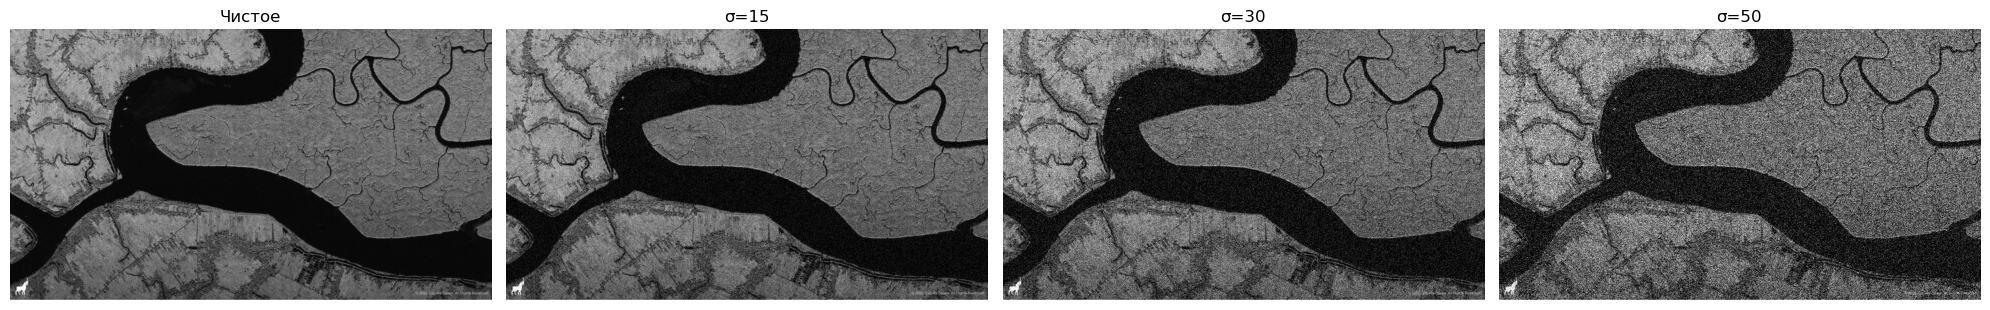

In [3]:
def add_gaussian_noise(image, mean=0, sigma=25):
    """Наложение гауссова шума: I + N(mean, sigma)."""
    noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)
    noisy = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy

img_gauss_low  = add_gaussian_noise(img_clean, sigma=15)
img_gauss_mid  = add_gaussian_noise(img_clean, sigma=30)
img_gauss_high = add_gaussian_noise(img_clean, sigma=50)

print("=== Гауссов шум ===")
for name, im in [('σ=15', img_gauss_low),
                 ('σ=30', img_gauss_mid),
                 ('σ=50', img_gauss_high)]:
    m, s = quality(img_clean, im)
    print(f"{name:>6} | MSE = {m:8.2f} | SSIM = {s:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, im, ttl in zip(axes,
                       [img_clean, img_gauss_low, img_gauss_mid, img_gauss_high],
                       ['Чистое', 'σ=15', 'σ=30', 'σ=50']):
    ax.imshow(im, cmap='gray'); ax.set_title(ttl); ax.axis('off')
plt.tight_layout(); plt.show()

=== Постоянный (равномерный) шум ===
   ±10 | MSE =    33.31 | SSIM = 0.8926
   ±30 | MSE =   272.32 | SSIM = 0.6153
   ±60 | MSE =  1058.35 | SSIM = 0.3426


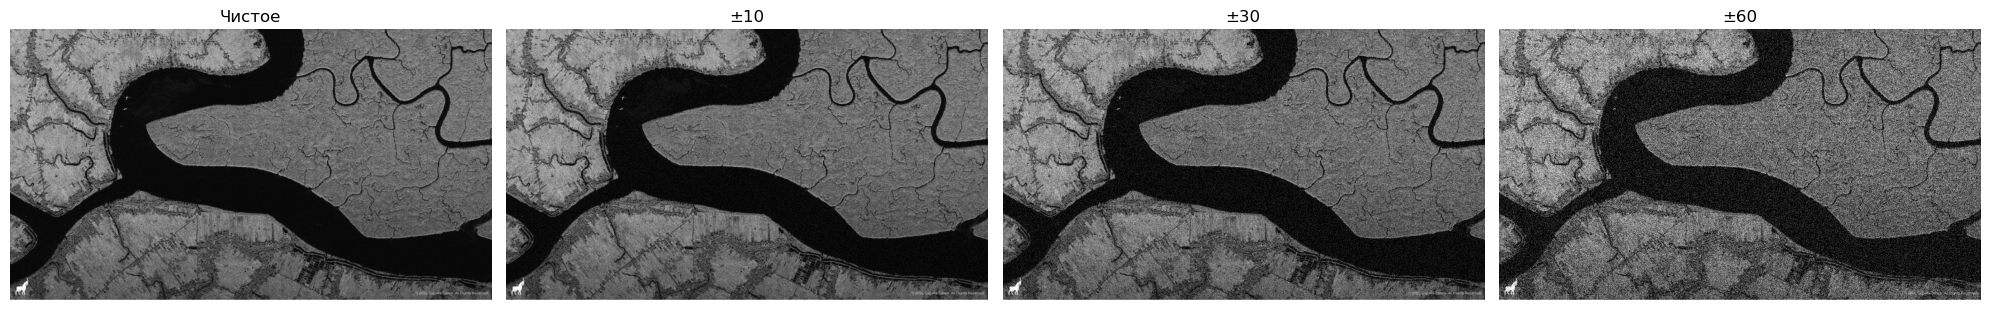

In [4]:
def add_uniform_noise(image, low=-30, high=30):
    """Постоянный (равномерный) шум: I + U(low, high)."""
    noise = np.random.uniform(low, high, image.shape).astype(np.float32)
    noisy = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy

img_uniform_low  = add_uniform_noise(img_clean, low=-10, high=10)
img_uniform_mid  = add_uniform_noise(img_clean, low=-30, high=30)
img_uniform_high = add_uniform_noise(img_clean, low=-60, high=60)

print("=== Постоянный (равномерный) шум ===")
for name, im in [('±10', img_uniform_low),
                 ('±30', img_uniform_mid),
                 ('±60', img_uniform_high)]:
    m, s = quality(img_clean, im)
    print(f"{name:>6} | MSE = {m:8.2f} | SSIM = {s:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, im, ttl in zip(axes,
                       [img_clean, img_uniform_low, img_uniform_mid, img_uniform_high],
                       ['Чистое', '±10', '±30', '±60']):
    ax.imshow(im, cmap='gray'); ax.set_title(ttl); ax.axis('off')
plt.tight_layout(); plt.show()

=== Медианный фильтр ===

--- Шум: gauss σ=30 ---
Без фильтра        | MSE =   793.90 | SSIM = 0.4013
medianBlur k=3   | MSE =   299.60 | SSIM = 0.4923
medianBlur k=5   | MSE =   295.81 | SSIM = 0.4558
medianBlur k=7   | MSE =   325.74 | SSIM = 0.4188

--- Шум: uniform ±30 ---
Без фильтра        | MSE =   272.32 | SSIM = 0.6153
medianBlur k=3   | MSE =   215.45 | SSIM = 0.5700
medianBlur k=5   | MSE =   260.39 | SSIM = 0.4939
medianBlur k=7   | MSE =   302.99 | SSIM = 0.4437


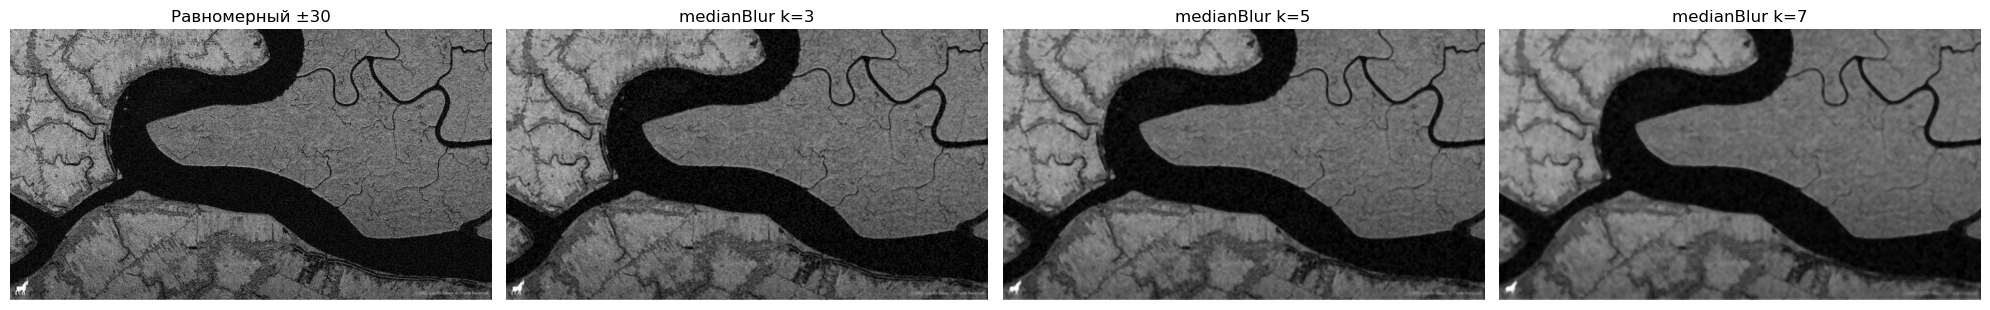

In [5]:
print("=== Медианный фильтр ===")
results_median = {}

for noise_name, noisy_img in [('gauss σ=30',   img_gauss_mid),
                              ('uniform ±30',  img_uniform_mid)]:
    print(f"\n--- Шум: {noise_name} ---")

    m0, s0 = quality(img_clean, noisy_img)
    print(f"{'Без фильтра':<18} | MSE = {m0:8.2f} | SSIM = {s0:.4f}")

    for ksize in [3, 5, 7]:
        filtered = cv2.medianBlur(noisy_img, ksize)
        m, s = quality(img_clean, filtered)
        results_median[(noise_name, ksize)] = (filtered, m, s)
        print(f"medianBlur k={ksize:<3} | MSE = {m:8.2f} | SSIM = {s:.4f}")

# Визуализация для равномерного шума
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_uniform_mid, cmap='gray')
axes[0].set_title('Равномерный ±30')
for ax, k in zip(axes[1:], [3, 5, 7]):
    ax.imshow(results_median[('uniform ±30', k)][0], cmap='gray')
    ax.set_title(f'medianBlur k={k}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

=== Фильтр Гаусса (GaussianBlur) ===

--- Шум: gauss σ=30 ---
k=3, σ=0    | MSE =   229.48 | SSIM = 0.5953
k=3, σ=1.0  | MSE =   232.85 | SSIM = 0.5876
k=3, σ=2.0  | MSE =   252.02 | SSIM = 0.5566
k=5, σ=0    | MSE =   231.12 | SSIM = 0.5830
k=5, σ=1.0  | MSE =   225.70 | SSIM = 0.5919
k=5, σ=2.0  | MSE =   272.01 | SSIM = 0.5197
k=7, σ=0    | MSE =   258.53 | SSIM = 0.5411
k=7, σ=1.0  | MSE =   226.50 | SSIM = 0.5903
k=7, σ=2.0  | MSE =   291.52 | SSIM = 0.4932

--- Шум: uniform ±30 ---
k=3, σ=0    | MSE =   144.89 | SSIM = 0.7135
k=3, σ=1.0  | MSE =   155.91 | SSIM = 0.6967
k=3, σ=2.0  | MSE =   182.57 | SSIM = 0.6538
k=5, σ=0    | MSE =   180.17 | SSIM = 0.6617
k=5, σ=1.0  | MSE =   170.43 | SSIM = 0.6772
k=5, σ=2.0  | MSE =   237.51 | SSIM = 0.5714
k=7, σ=0    | MSE =   225.15 | SSIM = 0.5919
k=7, σ=1.0  | MSE =   173.02 | SSIM = 0.6732
k=7, σ=2.0  | MSE =   265.26 | SSIM = 0.5310


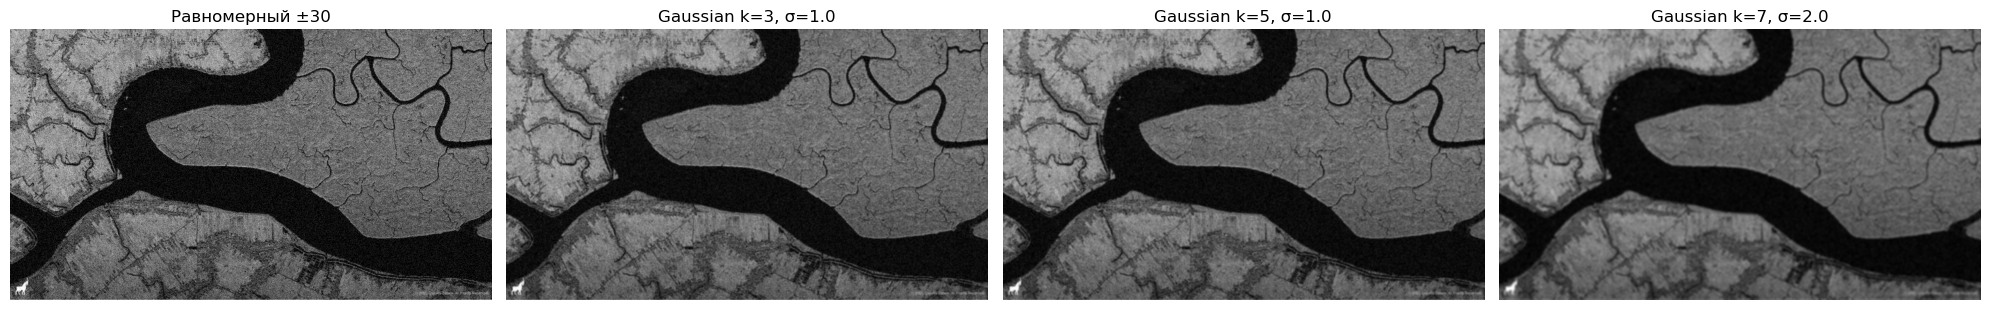

In [6]:
print("=== Фильтр Гаусса (GaussianBlur) ===")
results_gauss = {}

for noise_name, noisy_img in [('gauss σ=30',   img_gauss_mid),
                              ('uniform ±30',  img_uniform_mid)]:
    print(f"\n--- Шум: {noise_name} ---")
    for ksize in [3, 5, 7]:
        for sigma in [0, 1.0, 2.0]:
            filtered = cv2.GaussianBlur(noisy_img, (ksize, ksize), sigma)
            m, s = quality(img_clean, filtered)
            results_gauss[(noise_name, ksize, sigma)] = (filtered, m, s)
            print(f"k={ksize}, σ={sigma:<4} | MSE = {m:8.2f} | SSIM = {s:.4f}")

# Визуализация для равномерного шума
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_uniform_mid, cmap='gray')
axes[0].set_title('Равномерный ±30')
for ax, (k, sg) in zip(axes[1:], [(3, 1.0), (5, 1.0), (7, 2.0)]):
    ax.imshow(results_gauss[('uniform ±30', k, sg)][0], cmap='gray')
    ax.set_title(f'Gaussian k={k}, σ={sg}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

=== Билатеральный фильтр ===

--- Шум: gauss σ=30 ---
d=5, σColor=50  , σSpace=50   | MSE =   241.30 | SSIM = 0.6083
d=5, σColor=50  , σSpace=75   | MSE =   241.30 | SSIM = 0.6083
d=5, σColor=75  , σSpace=50   | MSE =   218.59 | SSIM = 0.6071
d=5, σColor=75  , σSpace=75   | MSE =   218.60 | SSIM = 0.6071
d=5, σColor=100 , σSpace=50   | MSE =   227.06 | SSIM = 0.5851
d=5, σColor=100 , σSpace=75   | MSE =   227.07 | SSIM = 0.5851
d=9, σColor=50  , σSpace=50   | MSE =   230.49 | SSIM = 0.6172
d=9, σColor=50  , σSpace=75   | MSE =   230.50 | SSIM = 0.6172
d=9, σColor=75  , σSpace=50   | MSE =   238.87 | SSIM = 0.5817
d=9, σColor=75  , σSpace=75   | MSE =   238.89 | SSIM = 0.5816
d=9, σColor=100 , σSpace=50   | MSE =   265.76 | SSIM = 0.5338
d=9, σColor=100 , σSpace=75   | MSE =   265.80 | SSIM = 0.5337

--- Шум: uniform ±30 ---
d=5, σColor=50  , σSpace=50   | MSE =   136.69 | SSIM = 0.7196
d=5, σColor=50  , σSpace=75   | MSE =   136.70 | SSIM = 0.7196
d=5, σColor=75  , σSpace=50   | MSE = 

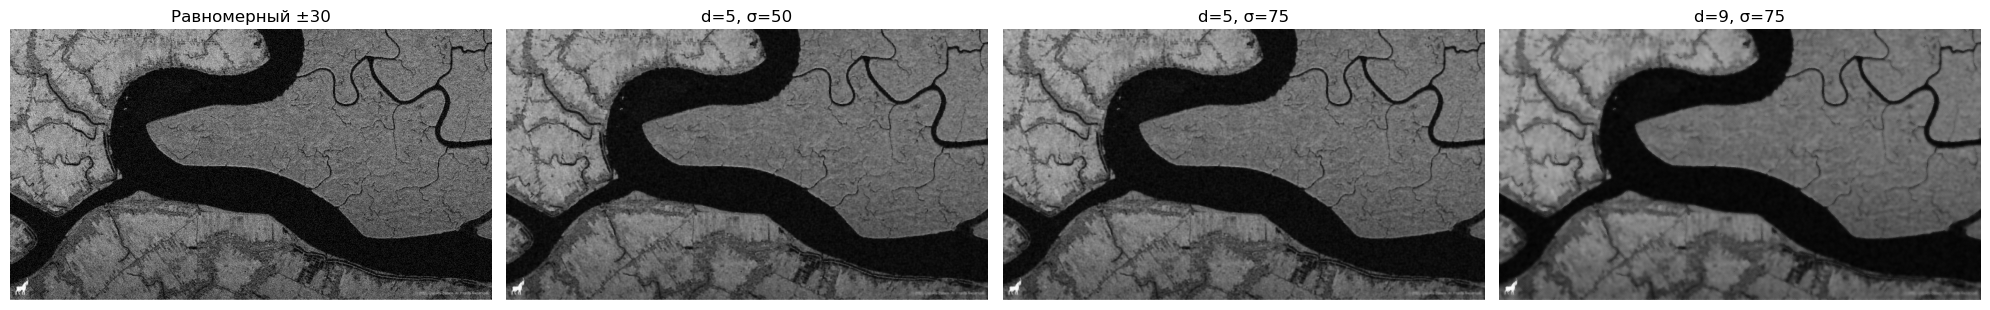

In [7]:
print("=== Билатеральный фильтр ===")
results_bilat = {}

for noise_name, noisy_img in [('gauss σ=30',   img_gauss_mid),
                              ('uniform ±30',  img_uniform_mid)]:
    print(f"\n--- Шум: {noise_name} ---")
    for d in [5, 9]:
        for sc in [50, 75, 100]:
            for ss in [50, 75]:
                filtered = cv2.bilateralFilter(noisy_img, d, sc, ss)
                m, s = quality(img_clean, filtered)
                results_bilat[(noise_name, d, sc, ss)] = (filtered, m, s)
                print(f"d={d}, σColor={sc:<4}, σSpace={ss:<4} "
                      f"| MSE = {m:8.2f} | SSIM = {s:.4f}")

# Визуализация для равномерного шума
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_uniform_mid, cmap='gray')
axes[0].set_title('Равномерный ±30')
for ax, (d, sc, ss) in zip(axes[1:], [(5, 50, 50), (5, 75, 75), (9, 75, 75)]):
    ax.imshow(results_bilat[('uniform ±30', d, sc, ss)][0], cmap='gray')
    ax.set_title(f'd={d}, σ={sc}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

=== Non-Local Means (fastNlMeansDenoising) ===

--- Шум: gauss σ=30 ---
NLM h=5   | MSE =   793.90 | SSIM = 0.4013
NLM h=10  | MSE =   776.97 | SSIM = 0.4090
NLM h=15  | MSE =   685.03 | SSIM = 0.5211
NLM h=20  | MSE =   321.76 | SSIM = 0.6294

--- Шум: uniform ±30 ---
NLM h=5   | MSE =   272.32 | SSIM = 0.6153
NLM h=10  | MSE =   232.83 | SSIM = 0.7399
NLM h=15  | MSE =   132.73 | SSIM = 0.7588
NLM h=20  | MSE =   174.49 | SSIM = 0.6215


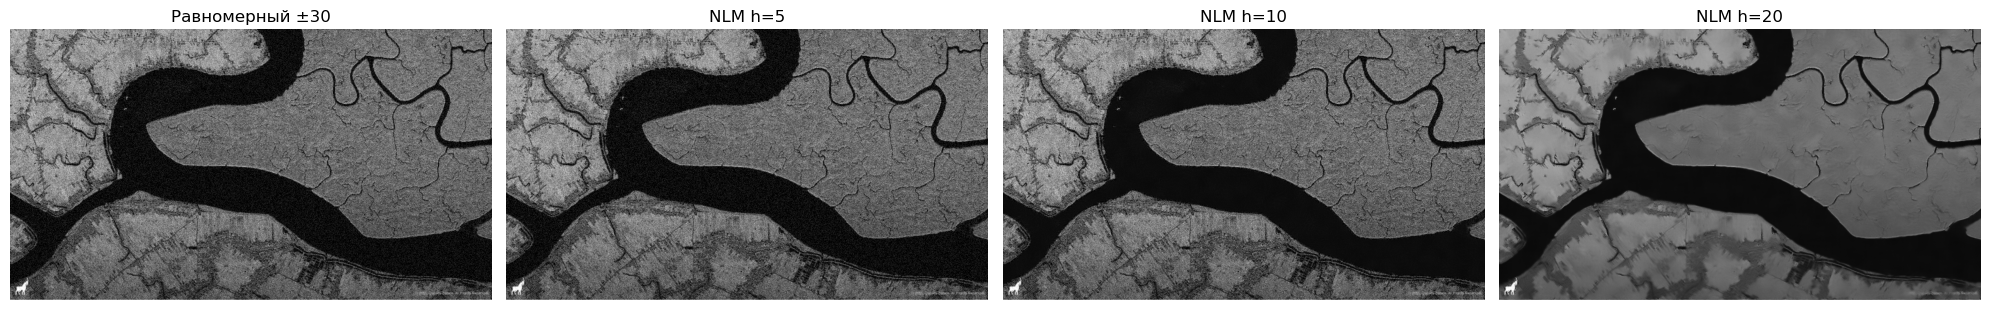

In [8]:
print("=== Non-Local Means (fastNlMeansDenoising) ===")
results_nlm = {}

for noise_name, noisy_img in [('gauss σ=30',   img_gauss_mid),
                              ('uniform ±30',  img_uniform_mid)]:
    print(f"\n--- Шум: {noise_name} ---")
    for h in [5, 10, 15, 20]:
        filtered = cv2.fastNlMeansDenoising(noisy_img, None,
                                            h=h,
                                            templateWindowSize=7,
                                            searchWindowSize=21)
        m, s = quality(img_clean, filtered)
        results_nlm[(noise_name, h)] = (filtered, m, s)
        print(f"NLM h={h:<3} | MSE = {m:8.2f} | SSIM = {s:.4f}")

# Визуализация для равномерного шума
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_uniform_mid, cmap='gray')
axes[0].set_title('Равномерный ±30')
for ax, h in zip(axes[1:], [5, 10, 20]):
    ax.imshow(results_nlm[('uniform ±30', h)][0], cmap='gray')
    ax.set_title(f'NLM h={h}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


=== Сводная таблица (гауссов шум σ=30) ===
                Метод               Параметры        MSE     SSIM
Bilateral (5, 75, 50) (gauss σ=30, 5, 75, 50) 218.588467 0.607093
  Gaussian k=5, σ=1.0    (gauss σ=30, 5, 1.0) 225.703715 0.591865
           Median k=5         (gauss σ=30, 5) 295.812912 0.455837
             NLM h=20        (gauss σ=30, 20) 321.763718 0.629373
          Зашумлённое                    None 793.899062 0.401257


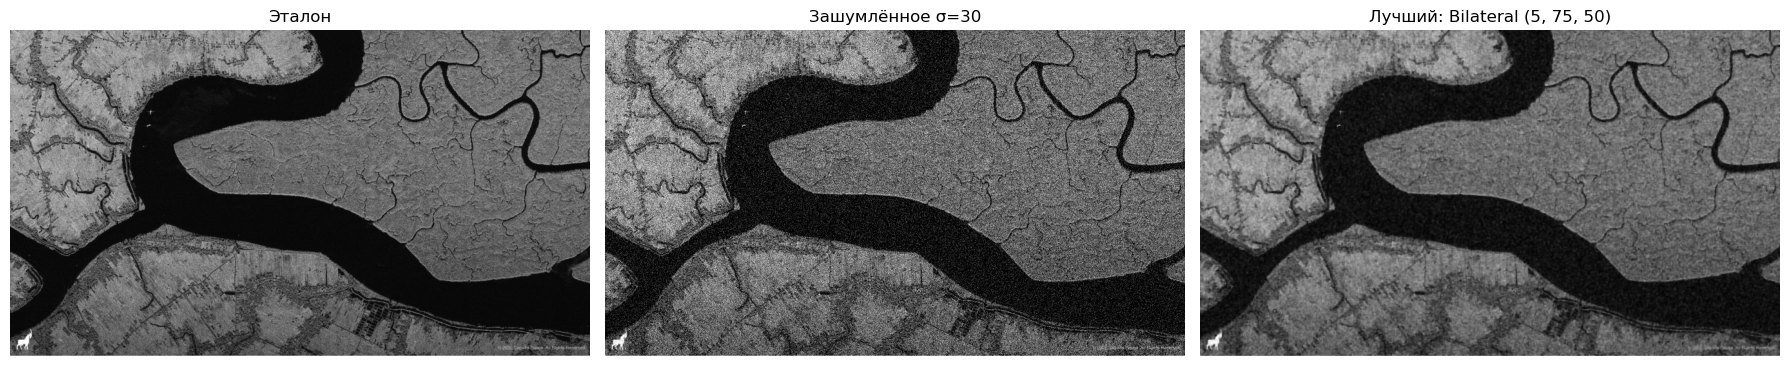


🏆 Лучший метод: Bilateral (5, 75, 50)
   MSE  = 218.59
   SSIM = 0.6071


In [9]:
noise_name = 'gauss σ=30'
noisy_img  = img_gauss_mid

best_median = min([(k, v) for k, v in results_median.items()
                   if k[0] == noise_name], key=lambda x: x[1][1])
best_gauss  = min([(k, v) for k, v in results_gauss.items()
                   if k[0] == noise_name], key=lambda x: x[1][1])
best_bilat  = min([(k, v) for k, v in results_bilat.items()
                   if k[0] == noise_name], key=lambda x: x[1][1])
best_nlm    = min([(k, v) for k, v in results_nlm.items()
                   if k[0] == noise_name], key=lambda x: x[1][1])

rows = [
    ('Зашумлённое', None, *quality(img_clean, noisy_img)),
    (f'Median k={best_median[0][1]}',
     best_median[0], best_median[1][1], best_median[1][2]),
    (f'Gaussian k={best_gauss[0][1]}, σ={best_gauss[0][2]}',
     best_gauss[0],  best_gauss[1][1],  best_gauss[1][2]),
    (f'Bilateral {best_bilat[0][1:]}',
     best_bilat[0],  best_bilat[1][1],  best_bilat[1][2]),
    (f'NLM h={best_nlm[0][1]}',
     best_nlm[0],    best_nlm[1][1],    best_nlm[1][2]),
]

df = pd.DataFrame(rows, columns=['Метод', 'Параметры', 'MSE', 'SSIM'])
df = df.sort_values('MSE')

print("\n=== Сводная таблица (гауссов шум σ=30) ===")
print(df.to_string(index=False))

# Визуальный финал
best_name = df.iloc[0, 0]
if 'NLM' in best_name:
    best_img = best_nlm[1][0]
elif 'Median' in best_name:
    best_img = best_median[1][0]
elif 'Gaussian' in best_name:
    best_img = best_gauss[1][0]
else:
    best_img = best_bilat[1][0]

best_mse  = df.iloc[0, 2]
best_ssim = df.iloc[0, 3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_clean, cmap='gray'); axes[0].set_title('Эталон'); axes[0].axis('off')
axes[1].imshow(noisy_img, cmap='gray'); axes[1].set_title('Зашумлённое σ=30'); axes[1].axis('off')
axes[2].imshow(best_img, cmap='gray');  axes[2].set_title(f'Лучший: {best_name}'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print(f"\n🏆 Лучший метод: {best_name}")
print(f"   MSE  = {best_mse:.2f}")
print(f"   SSIM = {best_ssim:.4f}")


=== Сводная таблица (равномерный шум ±30) ===
                Метод                Параметры        MSE     SSIM
             NLM h=15        (uniform ±30, 15) 132.725652 0.758812
Bilateral (5, 50, 50) (uniform ±30, 5, 50, 50) 136.691234 0.719595
    Gaussian k=3, σ=0      (uniform ±30, 3, 0) 144.886414 0.713524
           Median k=3         (uniform ±30, 3) 215.446836 0.570002
          Зашумлённое                     None 272.319778 0.615313


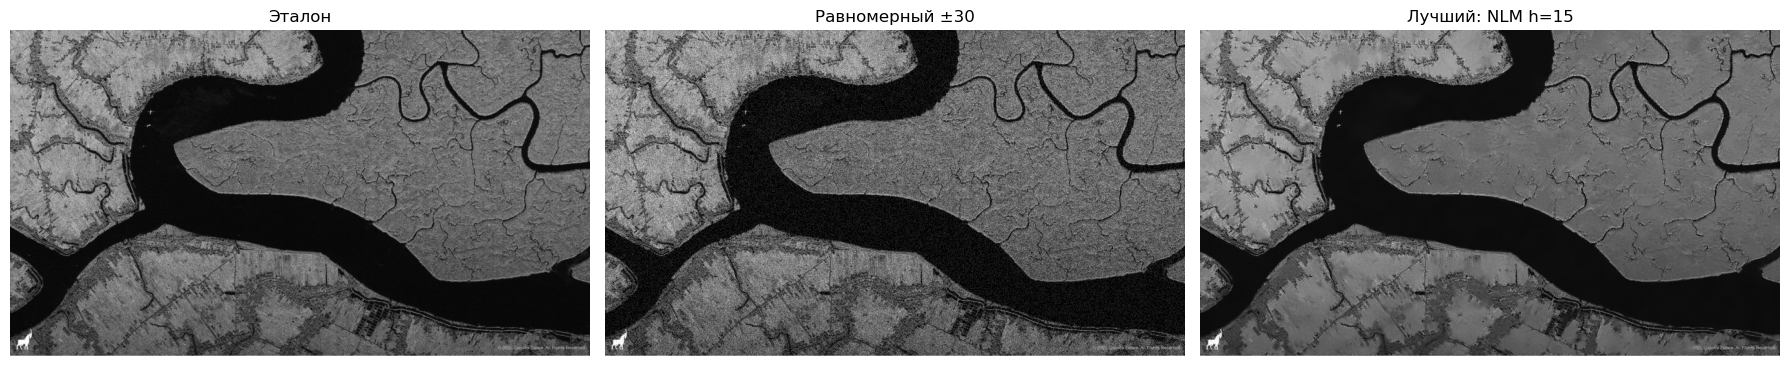


🏆 Лучший метод (равномерный шум): NLM h=15
   MSE  = 132.73
   SSIM = 0.7588


In [10]:
noise_name = 'uniform ±30'
noisy_img  = img_uniform_mid

best_median_u = min([(k, v) for k, v in results_median.items()
                     if k[0] == noise_name], key=lambda x: x[1][1])
best_gauss_u  = min([(k, v) for k, v in results_gauss.items()
                     if k[0] == noise_name], key=lambda x: x[1][1])
best_bilat_u  = min([(k, v) for k, v in results_bilat.items()
                     if k[0] == noise_name], key=lambda x: x[1][1])
best_nlm_u    = min([(k, v) for k, v in results_nlm.items()
                     if k[0] == noise_name], key=lambda x: x[1][1])

rows_u = [
    ('Зашумлённое', None, *quality(img_clean, noisy_img)),
    (f'Median k={best_median_u[0][1]}',
     best_median_u[0], best_median_u[1][1], best_median_u[1][2]),
    (f'Gaussian k={best_gauss_u[0][1]}, σ={best_gauss_u[0][2]}',
     best_gauss_u[0],  best_gauss_u[1][1],  best_gauss_u[1][2]),
    (f'Bilateral {best_bilat_u[0][1:]}',
     best_bilat_u[0],  best_bilat_u[1][1],  best_bilat_u[1][2]),
    (f'NLM h={best_nlm_u[0][1]}',
     best_nlm_u[0],    best_nlm_u[1][1],    best_nlm_u[1][2]),
]

df_u = pd.DataFrame(rows_u, columns=['Метод', 'Параметры', 'MSE', 'SSIM'])
df_u = df_u.sort_values('MSE')

print("\n=== Сводная таблица (равномерный шум ±30) ===")
print(df_u.to_string(index=False))

best_name_u = df_u.iloc[0, 0]
if 'NLM' in best_name_u:
    best_img_u = best_nlm_u[1][0]
elif 'Median' in best_name_u:
    best_img_u = best_median_u[1][0]
elif 'Gaussian' in best_name_u:
    best_img_u = best_gauss_u[1][0]
else:
    best_img_u = best_bilat_u[1][0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_clean, cmap='gray');   axes[0].set_title('Эталон'); axes[0].axis('off')
axes[1].imshow(noisy_img, cmap='gray');   axes[1].set_title('Равномерный ±30'); axes[1].axis('off')
axes[2].imshow(best_img_u, cmap='gray');  axes[2].set_title(f'Лучший: {best_name_u}'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print(f"\n🏆 Лучший метод (равномерный шум): {best_name_u}")
print(f"   MSE  = {df_u.iloc[0, 2]:.2f}")
print(f"   SSIM = {df_u.iloc[0, 3]:.4f}")